In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42); np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# MNIST 데이터 로딩
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")



device: cuda
Train: 60000, Test: 10000
Image shape: torch.Size([1, 28, 28])


# Part 1 합성곱 연산 직접 구현

#### Step 1 nn,Conv2d 기본 사용법

In [8]:
# 1채널 5x5 입력 생성 (batch=1)
input_1ch = torch.tensor([[1,2,0,1,3],
                          [0,1,2,3,1],
                          [1,3,1,0,2],
                          [2,1,0,1,1],
                          [0,2,1,3,0]], dtype=torch.float32)
input_1ch = input_1ch.unsqueeze(0).unsqueeze(0)  # (1,1,5,5)
print("입력 shape:", input_1ch.shape)

# Conv2d: in_channels=1, out_channels=1, kernel=3x3
conv = nn.Conv2d(1, 1, kernel_size=3, bias=False)
with torch.no_grad():
    conv.weight.copy_(torch.tensor([[1,0,-1],[1,0,-1],[1,0,-1]],
                                    dtype=torch.float32).reshape(1,1,3,3))

output = conv(input_1ch)
print("출력 shape:", output.shape)
print("출력 값:\n", output.squeeze().detach().numpy())


입력 shape: torch.Size([1, 1, 5, 5])
출력 shape: torch.Size([1, 1, 3, 3])
출력 값:
 [[-1.  2. -3.]
 [ 0.  1. -1.]
 [ 1.  2. -1.]]


#### Step 2 수동 합성곱 vs Conv2d 비교

In [9]:
# 수동 합성곱 구현
def manual_conv2d(input_2d, kernel_2d):
    H, W = input_2d.shape
    kH, kW = kernel_2d.shape
    oH, oW = H - kH + 1, W - kW + 1
    output = torch.zeros(oH, oW)
    for i in range(oH):
        for j in range(oW):
            patch = input_2d[i:i+kH, j:j+kW]
            output[i, j] = (patch * kernel_2d).sum()
    return output

kernel = torch.tensor([[1,0,-1],[1,0,-1],[1,0,-1]],
                       dtype=torch.float32)
manual_out = manual_conv2d(input_1ch.squeeze(), kernel)
conv2d_out = output.squeeze().detach()

print("수동 결과:\n", manual_out.numpy())
print("Conv2d 결과:\n", conv2d_out.numpy())
print("동일한가?", torch.allclose(manual_out, conv2d_out))


수동 결과:
 [[-1.  2. -3.]
 [ 0.  1. -1.]
 [ 1.  2. -1.]]
Conv2d 결과:
 [[-1.  2. -3.]
 [ 0.  1. -1.]
 [ 1.  2. -1.]]
동일한가? True


# Part 2 패딩과 스트라이드

#### step 1 패딩에 따른 출력 크기 변화

In [10]:
x = torch.randn(1, 1, 7, 7)  # 7x7 입력

# Valid 패딩 (P=0)
conv_valid = nn.Conv2d(1, 1, kernel_size=3, padding=0)
out_valid = conv_valid(x)
print(f"P=0 (Valid): {x.shape} → {out_valid.shape}")
print(f"  공식: (7-3+0)/1+1 = 5")

# Same 패딩 (P=1)
conv_same = nn.Conv2d(1, 1, kernel_size=3, padding=1)
out_same = conv_same(x)
print(f"P=1 (Same):  {x.shape} → {out_same.shape}")
print(f"  공식: (7-3+2)/1+1 = 7")

# P=2
conv_p2 = nn.Conv2d(1, 1, kernel_size=3, padding=2)
out_p2 = conv_p2(x)
print(f"P=2:         {x.shape} → {out_p2.shape}")
print(f"  공식: (7-3+4)/1+1 = 9")


P=0 (Valid): torch.Size([1, 1, 7, 7]) → torch.Size([1, 1, 5, 5])
  공식: (7-3+0)/1+1 = 5
P=1 (Same):  torch.Size([1, 1, 7, 7]) → torch.Size([1, 1, 7, 7])
  공식: (7-3+2)/1+1 = 7
P=2:         torch.Size([1, 1, 7, 7]) → torch.Size([1, 1, 9, 9])
  공식: (7-3+4)/1+1 = 9


#### Step 2 스트라이드에 따른 출력 크기 변화

In [11]:
x = torch.randn(1, 1, 8, 8)  # 8x8 입력

for s in [1, 2, 4]:
    conv_s = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=s)
    out_s = conv_s(x)
    print(f"S={s}: {x.shape[2]}x{x.shape[3]} → "
          f"{out_s.shape[2]}x{out_s.shape[3]}")

print("\n--- 스트라이드 합성곱 vs 풀링 비교 ---")
x2 = torch.randn(1, 1, 8, 8)
# 스트라이드 합성곱으로 다운샘플링
out_stride = nn.Conv2d(1,1,3,padding=1,stride=2)(x2)
# Conv(S=1) + MaxPool로 다운샘플링
out_pool = nn.MaxPool2d(2)(nn.Conv2d(1,1,3,padding=1)(x2))
print(f"Stride Conv: {out_stride.shape}")
print(f"Conv+Pool:   {out_pool.shape}")


S=1: 8x8 → 8x8
S=2: 8x8 → 4x4
S=4: 8x8 → 2x2

--- 스트라이드 합성곱 vs 풀링 비교 ---
Stride Conv: torch.Size([1, 1, 4, 4])
Conv+Pool:   torch.Size([1, 1, 4, 4])


#### Step 3 출력 크기 공식 검증 함수

In [12]:
def calc_output_size(I, K, P, S):
    return (I - K + 2*P) // S + 1

# 강의 자료 연습문제 검증
cases = [
    ("Q1: 32x32, K=5, P=2, S=1", 32, 5, 2, 1),
    ("Q2: 28x28, K=3, P=0, S=2", 28, 3, 0, 2),
    ("Q3: 64x64, K=3, P=1, S=1", 64, 3, 1, 1),
    ("Q4: 224x224, K=7, P=3, S=2", 224, 7, 3, 2),
]
for name, I, K, P, S in cases:
    pred = calc_output_size(I, K, P, S)
    x = torch.randn(1, 1, I, I)
    conv = nn.Conv2d(1, 1, K, padding=P, stride=S)
    actual = conv(x).shape[2]
    match = '✓' if pred == actual else '✗'
    print(f"{match} {name} → 공식:{pred}, 실제:{actual}")


✓ Q1: 32x32, K=5, P=2, S=1 → 공식:32, 실제:32
✓ Q2: 28x28, K=3, P=0, S=2 → 공식:13, 실제:13
✓ Q3: 64x64, K=3, P=1, S=1 → 공식:64, 실제:64
✓ Q4: 224x224, K=7, P=3, S=2 → 공식:112, 실제:112


# Part 3 풀링 레이어

#### Step 1 MaxPool vs AvgPool

In [13]:
x = torch.tensor([[3,5,4,6],
                   [1,1,9,4],
                   [7,10,9,5],
                   [12,2,9,4]], dtype=torch.float32)
x = x.unsqueeze(0).unsqueeze(0)  # (1,1,4,4)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

print("입력 (4x4):")
print(x.squeeze().numpy())
print(f"\nMaxPool 결과:")
print(max_pool(x).squeeze().numpy())
print(f"\nAvgPool 결과:")
print(avg_pool(x).squeeze().numpy())
print("\n→ MaxPool: 강한 특징 보존 / AvgPool: 전체 평균")


입력 (4x4):
[[ 3.  5.  4.  6.]
 [ 1.  1.  9.  4.]
 [ 7. 10.  9.  5.]
 [12.  2.  9.  4.]]

MaxPool 결과:
[[ 5.  9.]
 [12.  9.]]

AvgPool 결과:
[[2.5  5.75]
 [7.75 6.75]]

→ MaxPool: 강한 특징 보존 / AvgPool: 전체 평균


#### Step 2 풀링의 이동 불변성

In [14]:
# 풀링의 이동 불변성(Translation Invariance)
x1 = torch.zeros(1,1,6,6)
x1[0,0,1,1] = 10.0  # 특징이 (1,1) 위치

x2 = torch.zeros(1,1,6,6)
x2[0,0,2,2] = 10.0  # 특징이 (2,2) 위치 (이동됨)

pool = nn.MaxPool2d(kernel_size=3, stride=3)
print("x1 (특징 위치: 1,1):")
print(pool(x1).squeeze().numpy())
print("\nx2 (특징 위치: 2,2):")
print(pool(x2).squeeze().numpy())
print("\n결과 동일?:", torch.equal(pool(x1), pool(x2)))
print("→ 풀링은 수용 영역 내 이동에 불변!")

# 수용 영역 밖으로 이동
x3 = torch.zeros(1,1,6,6)
x3[0,0,3,3] = 10.0  # 다른 풀링 영역
print("\nx3 (특징 위치: 3,3):")
print(pool(x3).squeeze().numpy())
print("→ 수용 영역 밖 이동은 다른 결과")


x1 (특징 위치: 1,1):
[[10.  0.]
 [ 0.  0.]]

x2 (특징 위치: 2,2):
[[10.  0.]
 [ 0.  0.]]

결과 동일?: True
→ 풀링은 수용 영역 내 이동에 불변!

x3 (특징 위치: 3,3):
[[ 0.  0.]
 [ 0. 10.]]
→ 수용 영역 밖 이동은 다른 결과


# Part 4 CNN으로 MNIST

#### Step 1 기존 MLP 모델 정의 (비교 대상)

In [15]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1*28*28, 1000)   # 입력: 784
        self.fc2 = nn.Linear(1000, 500)
        self.fc3 = nn.Linear(500, 10)          # 출력: 10 클래스

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

mlp_model = SimpleMLP().to(device)
print(mlp_model)

total_mlp = sum(p.numel() for p in mlp_model.parameters())
print(f"\nTotal MLP params: {total_mlp:,}")
# → 약 1.29M개 (CNN 대비 훨씬 많음!)


SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=1000, bias=True)
  (fc2): Linear(in_features=1000, out_features=500, bias=True)
  (fc3): Linear(in_features=500, out_features=10, bias=True)
)

Total MLP params: 1,290,510


#### Step 2 MLP 학습 - 성능 기준선 확보

In [16]:
# MLP 학습 (5 에포크)
optimizer_mlp = torch.optim.Adam(mlp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    mlp_model.train(); total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        loss = criterion(mlp_model(X), y)
        optimizer_mlp.zero_grad(); loss.backward(); optimizer_mlp.step()
        total_loss += loss.item()

    mlp_model.eval()
    correct = sum((mlp_model(X.to(device)).argmax(1)==y.to(device)).sum().item()
                  for X,y in test_loader)
    print(f"MLP Epoch {epoch+1} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Test Acc: {correct/10000:.4f}")

print(f"\n--- MLP 최종 ---")
print(f"파라미터 수: {sum(p.numel() for p in mlp_model.parameters()):,}")
print(f"Test Acc:   {correct/10000:.4f}")


MLP Epoch 1 | Loss: 0.2087 | Test Acc: 0.9588
MLP Epoch 2 | Loss: 0.0794 | Test Acc: 0.9728
MLP Epoch 3 | Loss: 0.0541 | Test Acc: 0.9758
MLP Epoch 4 | Loss: 0.0380 | Test Acc: 0.9794
MLP Epoch 5 | Loss: 0.0297 | Test Acc: 0.9805

--- MLP 최종 ---
파라미터 수: 1,290,510
Test Acc:   0.9805


#### Step 3 CNN 모델 정의 - 같은 작업, 다른 구조

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv Block 1: 1ch→16ch, 28x28→14x14
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Conv Block 2: 16ch→32ch, 14x14→7x7
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Classifier
        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # (B,16,14,14)
        x = self.pool(F.relu(self.conv2(x)))  # (B,32,7,7)
        x = x.view(x.size(0), -1)             # (B,1568)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SimpleCNN().to(device)
print(model)
total = sum(p.numel() for p in model.parameters())
print(f"\nTotal params: {total:,}")


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total params: 206,922


#### Step 4 CNN 학습 + MLP - CNN 비교

In [18]:
# CNN 학습 (5 에포크)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
for epoch in range(5):
    model.train(); total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        loss = criterion(model(X), y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    model.eval()
    correct = sum((model(X.to(device)).argmax(1)==y.to(device)).sum().item()
                  for X,y in test_loader)
    print(f"CNN Epoch {epoch+1} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Test Acc: {correct/10000:.4f}")

# ===== MLP vs CNN 최종 비교 =====
mlp_p = sum(p.numel() for p in mlp_model.parameters())
cnn_p = sum(p.numel() for p in model.parameters())
print(f"\n{'='*40}")
print(f" MLP params: {mlp_p:,}")
print(f" CNN params: {cnn_p:,}")
print(f" CNN은 파라미터가 {mlp_p/cnn_p:.1f}배 적고, 정확도는 더 높음!")
print(f"{'='*40}")


CNN Epoch 1 | Loss: 0.2364 | Test Acc: 0.9805
CNN Epoch 2 | Loss: 0.0605 | Test Acc: 0.9835
CNN Epoch 3 | Loss: 0.0426 | Test Acc: 0.9869
CNN Epoch 4 | Loss: 0.0342 | Test Acc: 0.9832
CNN Epoch 5 | Loss: 0.0269 | Test Acc: 0.9895

 MLP params: 1,290,510
 CNN params: 206,922
 CNN은 파라미터가 6.2배 적고, 정확도는 더 높음!


#### Step 5 Feature Map 시각화

/tmp/ipykernel_361/3166797348.py:30: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_361/3166797348.py:30: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_361/3166797348.py:30: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_361/3166797348.py:30: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_361/3166797348.py:30: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_361/3166797348.py:30: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151

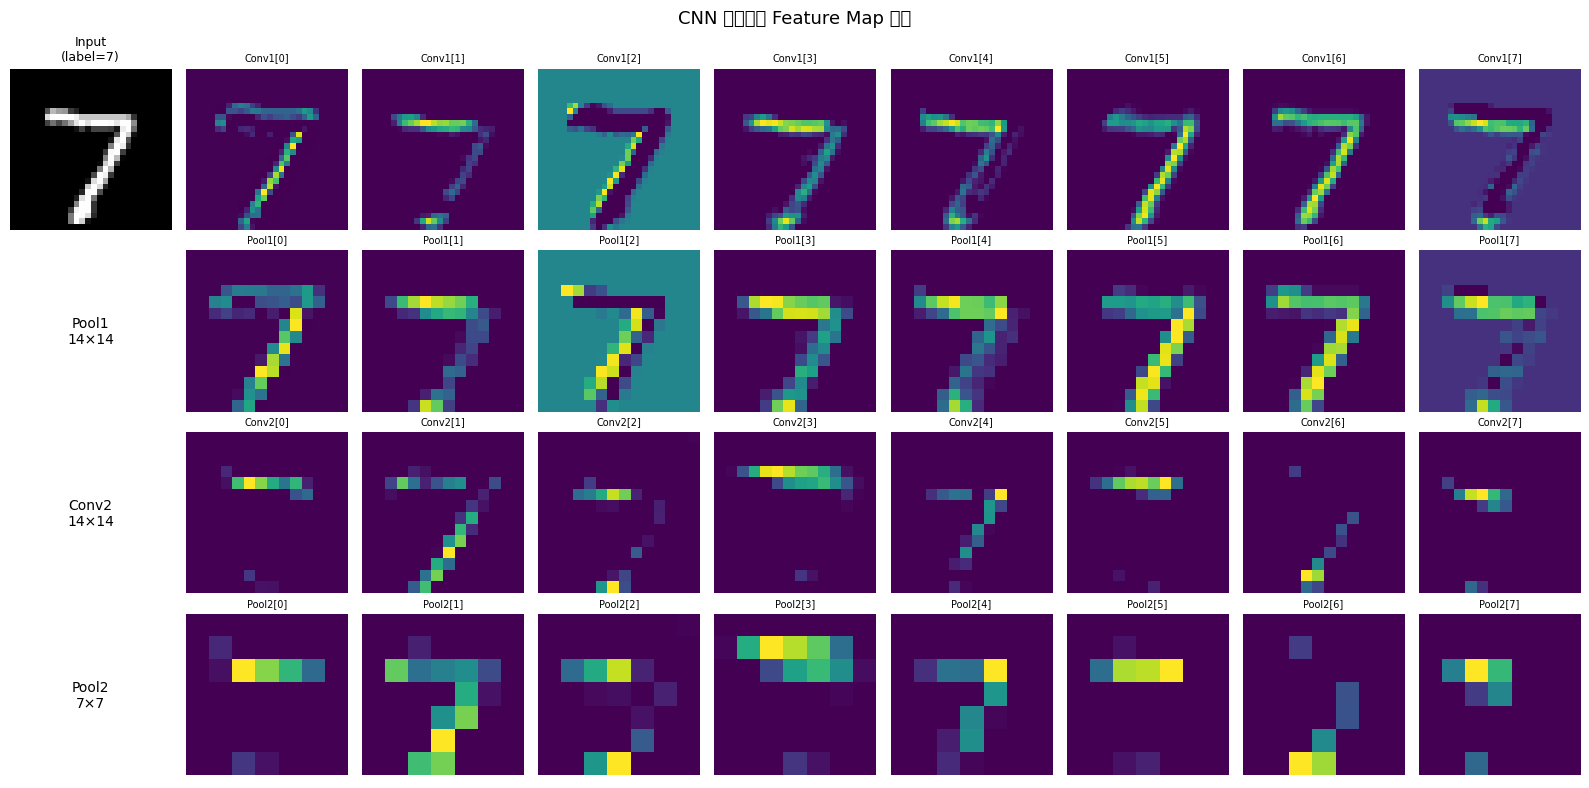

In [19]:
# 테스트 이미지 1장 선택
img, label = test_dataset[0]
img_input = img.unsqueeze(0).to(device)  # (1,1,28,28)

# 각 레이어별 중간 출력(feature map) 추출
with torch.no_grad():
    fm1 = F.relu(model.conv1(img_input))        # Conv1 → (1,16,28,28)
    fm1p = model.pool(fm1)                       # Pool1 → (1,16,14,14)
    fm2 = F.relu(model.conv2(fm1p))              # Conv2 → (1,32,14,14)
    fm2p = model.pool(fm2)                       # Pool2 → (1,32,7,7)

# 시각화: 원본 → Conv1 → Pool1 → Conv2 → Pool2
fig, axes = plt.subplots(4, 9, figsize=(16,8))
axes[0,0].imshow(img.squeeze(), cmap='gray')
axes[0,0].set_title(f'Input\n(label={label})', fontsize=9)
for i in range(8):
    axes[0, i+1].imshow(fm1[0,i].cpu(), cmap='viridis')
    axes[0, i+1].set_title(f'Conv1[{i}]', fontsize=7)
    axes[1, i+1].imshow(fm1p[0,i].cpu(), cmap='viridis')
    axes[1, i+1].set_title(f'Pool1[{i}]', fontsize=7)
    axes[2, i+1].imshow(fm2[0,i].cpu(), cmap='viridis')
    axes[2, i+1].set_title(f'Conv2[{i}]', fontsize=7)
    axes[3, i+1].imshow(fm2p[0,i].cpu(), cmap='viridis')
    axes[3, i+1].set_title(f'Pool2[{i}]', fontsize=7)
axes[1,0].text(0.5,0.5,'Pool1\n14×14',ha='center',va='center',fontsize=10,transform=axes[1,0].transAxes)
axes[2,0].text(0.5,0.5,'Conv2\n14×14',ha='center',va='center',fontsize=10,transform=axes[2,0].transAxes)
axes[3,0].text(0.5,0.5,'Pool2\n7×7',ha='center',va='center',fontsize=10,transform=axes[3,0].transAxes)
for ax in axes.flat: ax.axis('off')
plt.suptitle('CNN 레이어별 Feature Map 변화', fontsize=13)
plt.tight_layout(); plt.show()


#### Step 6 Label과 예측값

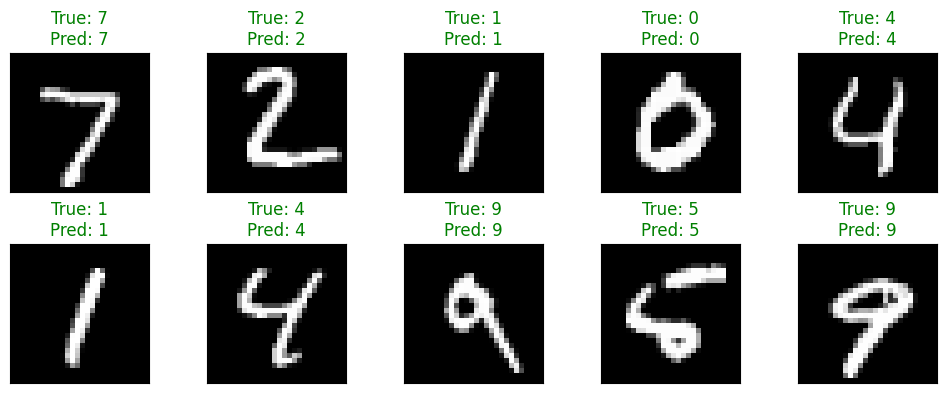

In [20]:
import matplotlib.pyplot as plt

# Get a batch of test images and labels
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move images to the device for prediction
images = images.to(device)

# Get predictions from the model
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Move images and labels back to CPU for plotting
images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

# Plot the images with actual and predicted labels
fig = plt.figure(figsize=(10, 4))
for idx in np.arange(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    ax.imshow(images[idx].squeeze(), cmap='gray')
    ax.set_title(f'True: {labels[idx].item()}\nPred: {predicted[idx].item()}',
                 color=('green' if predicted[idx] == labels[idx] else 'red'))
plt.tight_layout()
plt.show()
